# M2A2 - Correspondências de Características

Na aula de hoje vamos aprender como fazer convoluções utilizando [OpenCV](https://opencv.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Extração de Características
- Correspodências de Características
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable


Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
# TODO Atualize o path da imagens.
image_1 = cv2.imread("./1.jpeg")
image_2 = cv2.imread("./2.jpeg")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB))
plt.show()

NameError: name 'cv2' is not defined

## Extração de Características

Vamos extrair características utilizando o ORB.

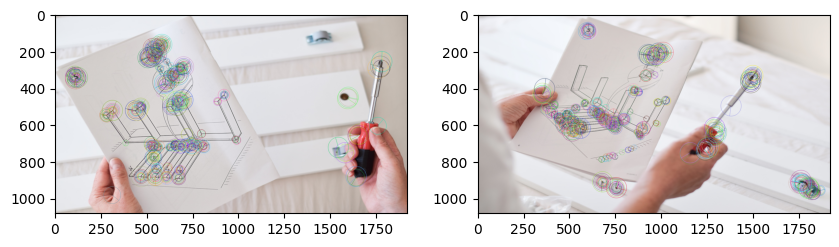

In [5]:
# Criando o detector do ORB.
orb = cv2.ORB_create()

# Detectando os keypoints nas imagens.
kp1, des1 = orb.detectAndCompute(image_1,None)
kp2, des2 = orb.detectAndCompute(image_2,None)

# Visualização de keypoints.
image_1_kp = cv2.drawKeypoints(image_1, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_2_kp = cv2.drawKeypoints(image_2, kp2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(cv2.cvtColor(image_1_kp, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(image_2_kp, cv2.COLOR_BGR2RGB))
plt.show()

## Correspodências de Características

Vamos comparar todos os keypoints de ambas as imagens e encontrar correspodências entre essas imagens.

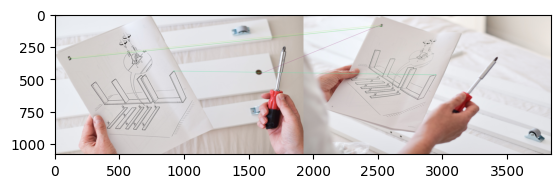

In [6]:
# Criando o matcher de força bruta.
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
 
# Realizando o matching entre os descritores.
matches = bf.match(des1,des2)
 
# Ordenando os matches com menor distância.
matches = sorted(matches, key = lambda x:x.distance)
 
# Desenhar os 5 matches mais próximos.
num = 5
image_matches = cv2.drawMatches(cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB), kp1, cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB), kp2, matches[:num], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
 
plt.imshow(image_matches)

## Próximos Passos e Referências

Nas próximas práticas iremos começar a utilizar modelos de aprendizado profundo, espero vocês lá.

Uma lista não exaustiva de referências segue:

- https://opencv.org/
- https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [ ] Rode a prática com outro conjunto de imanges.
- [ ] É possível utilizar outros descritores, por exemplo o SIFT?